CUSTOMER CHURN PREDICTION USING ANN

In [5]:
import numpy as np
import pandas as pd

In [6]:
df = pd.read_csv(r"C:\Users\ayush\OneDrive\Desktop\Churn_Modelling (1).csv")
df.head(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [10]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [11]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [12]:
df.drop(columns = ['RowNumber', 'CustomerId', 'Surname'], inplace=True)

In [13]:
df = pd.get_dummies(df, columns=['Geography','Gender'],drop_first=True,dtype = int)


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
x = df.drop(columns = ['Exited'])
y = df['Exited']

In [15]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [16]:
sc = StandardScaler()
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

In [17]:
!pip install tensorflow
import tensorflow 


In [18]:
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [19]:
model =  Sequential()

model.add(Dense(3,activation = 'relu',input_dim = 11))
model.add(Dense(1,activation = 'sigmoid'))

C:\Users\ayush\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 40 (160.00 B)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(loss = 'binary_crossentropy',optimizer = 'adam',metrics = ['accuracy'])
hist = model.fit(x_train_scaled,y_train,epochs = 100)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7945 - loss: 0.5671
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7945 - loss: 0.5021
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7945 - loss: 0.4707
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7945 - loss: 0.4531
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7945 - loss: 0.4439
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7945 - loss: 0.4391
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7945 - loss: 0.4364
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7945 - loss: 0.4347
Epoch 9/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7945 - loss: 0.4331
Epoch 10/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7945 - loss: 0.4318
Epoch 11/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7945 - loss: 0.4303
Epoch 12/100
250/250 ━━━━━━━━━━━━━━━━━━━━

In [22]:
accuracy = model.evaluate(x_test_scaled,y_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8425 - loss: 0.3880


In [23]:
model.layers[1].get_weights()

[array([[-1.6574926 ],
        [-0.7328298 ],
        [-0.34817094]], dtype=float32),
 array([1.6424423], dtype=float32)]

In [24]:
ab = model.predict(x_test_scaled)
y_pred = np.where(ab > 0.5, 1, 0)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [25]:
import matplotlib.pyplot as plt
hist.history

{'accuracy': [0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.7944999933242798,
  0.8075000047683716,
  0.8217499852180481,
  0.8236250281333923,
  0.8262500166893005,
  0.827750027179718,
  0.828374981880188,
  0.8293750286102295,
  0.8298749923706055,
  0.8321250081062317,
  0.8320000171661377,
  0.8327500224113464,
  0.8322499990463257,
  0.8347499966621399,
  0.8328750133514404,
  0.8338750004768372,
  0.8338750004768372,
  0.8348749876022339,
  0.8342499732971191,
  0.8343750238418579,
  0.8337500095367432,
  0.8348749876022339,
  0.8348749876022339,
  0.8348749876022339,
  0.8345000147819519,
  0.8346250057220459,
  0.8343750238418579,
  0.8352500200271606,
  0.8342499732971191,
  0.8349999785423279,
  0.8355000019073486,
  0.8353750109672546,


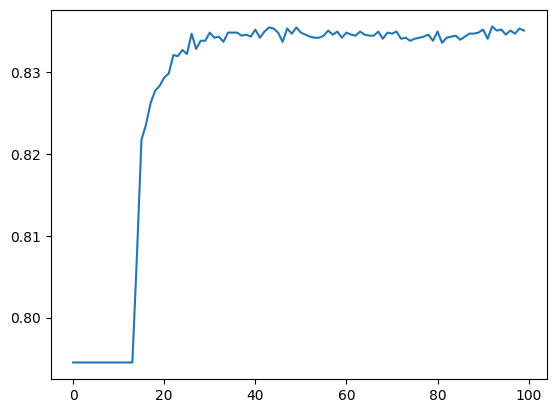

In [26]:
plt.plot(hist.history['accuracy'])

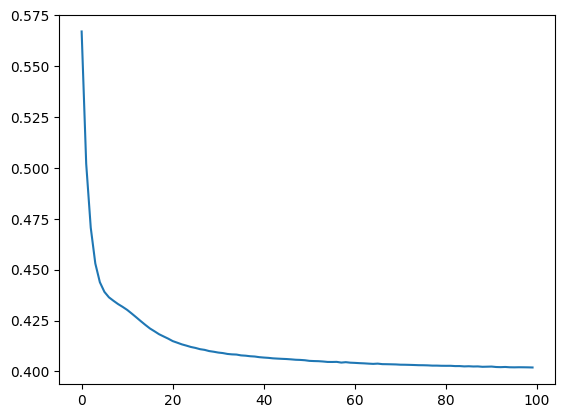

In [27]:
plt.plot(hist.history['loss'])

In [28]:
import pickle
model.save("churn_model.h5")

with open("scaler.pkl", "wb") as f:
    pickle.dump(sc, f)
